#####                           **UNIVERSIDADE DE SÃO PAULO**
 
#####                                **MBA USP ESALQ**		
		
**Estruturação metodológica para apoio à mediação de conflitos socioambientais**	
	
Aluna: Leticia Pereira Lira

Orientadora: Samira Sestari Nascimento 		
		
2026

-----------------------------
Trabalho de Conclusão de Curso apresentado para obtenção do título de especialista em Gestão de Projetos

-----------------------------

Detalhamento metodológico e resultados referentes aos módulos:
- Módulo II: Avaliação de Risco Ambiental
- Módulo III: Planejamento da Mitigação do Risco

------------------------------

In [0]:
%pip install numpy scikit-fuzzy networkx
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


#### **NÍVEL DE IMPACTO**

Nível de impacto do risco (I): representa a magnitude das consequências do risco (Sanchéz, 2013), que será definida pela relação entre as variáveis de Toxicidade do agrotóxico (intensidade do dano ao organismo) e de reversibilidade do agravo (capacidade de resposta do organismo ao dano) sobre a saúde humana (efeito) num determinado período.

**Conceitos Básicos:**

- O **risco** é a contaminação por agrotóxicos.

- As **consequências ou efeitos do risco** são as doenças provocadas por ele.

- A **Toxicidade** é a capacidade intrínseca de uma substância química ou agente físico de produzir um efeito nocivo e causar danos a um organismo vivo.

- O **Reversibilidade do Agravo** indica o potencial de reversibilidade do dano sobre a saúde humana, relacionado a temporalidade dos sintomas, categorizado por reversível, controlável e irreversível.









##### **AGRAVOS DE SAÚDE**

Os agravos de saúde são ilustrativos e foram selecionados apenas para demonstrar os diferentes níveis de reversibilidade dos danos. Abaixo tem-se a classificação dos agravos de acordo com as diretrizes do Ministério da Saúde [MS] (2018) e dos critérios do “National Cancer Institute” [NCI] (2025).

----------------------------------------

Para o Ministério da Saúde (Portaria nº 79, de 14 de dezembro de 2018) a classificação para agravos de saúde  é:
- Leve: "Sinais ou Sintomas leves, autoresolutivos ou transitórios"
- Moderado: "Sinais ou sintomas pronunciados ou prolongados"
- Grave: "Sinais e sintomas que ameaçam a vida do paciente"

Para o CTCAE a classificação para agravos de saúde  é:
- Leve: Assintomático ou sintomas leves; apenas observações clínicas ou diagnósticas; intervenção não indicada
- Moderado: Intervenção mínima, local ou não invasiva indicada; limitação nas atividades instrumentais de vida diária (AIVD) ou impacto leve/moderado nas atividades diárias normais adequadas à idade (pediatria)*
- Grave: Clinicamente significativo, mas sem risco imediato de morte; hospitalização ou prolongamento da hospitalização indicados; incapacitante; limitação nas atividades de autocuidado (AVD) ou impacto grave nas atividades diárias normais adequadas à idade (pediatria)**
- Risco de Morte: Consequências com risco de morte; intervenção urgente indicada.
- Morte relacionada ao evento adverso (EA).

------------------------------------------

**1 Intoxicação Exógena**

**Portaria nº 79, de 14 de dezembro de 2018 - Ministério da Saúde**

Leve:
- Vômito
- Irritação na pele e nos olhos
- Falta de ar, dispneia leve
- Vertigem

Valida os sintomas imediatos e agudos (gastrointestinais, respiratórios, neurológicos agudos) e o protocolo de reversão do quadro via suporte médico e antídotos.

**National Cancer Institute CTCAE (Common Terminology Criteria for Adverse Events**)

Leve e Moderado:
- Define que esses graus exigem apenas intervenção mínima, não invasiva, ou tratamento de suporte imediato. Cessada a exposição e aplicado o manejo, o quadro clínico é revertido e o paciente retorna ao estado basal sem sequelas permanentes.

**2 Síndrome Metabólica**

**Portaria nº 79, de 14 de dezembro de 2018 - Ministério da Saúde**

Leve:
- Hipoglicemia/ hipertensão leves e transitórias
- Hipoglicemia discreta (~ 50-70 mg / dl ou 2,8-3,9 mmol / l em adultos)
- Aumento discreto de enzimas séricas (ASAT, ALT ~ 2-5 x normal)

Moderado: 
- Hipertensão mais pronunciada
- Hipoglicemia mais pronunciada (~ 30-50 mg / dl ou 1,7-2,8 mmol / l em adultos)
- Aumento das enzimas séricas (ASAT, ALT~ 5-50 x normal)

Aponta a necessidade de monitoramento de parâmetros bioquímicos, hepáticos e metabólicos sistêmicos decorrentes da exposição crônica ou subcrônica.

**National Cancer Institute CTCAE (Common Terminology Criteria for Adverse Events**)

Moderado e Grave:
- Define o Grau 3 nesta categoria como uma condição que requer intervenção médica ou terapêutica contínua (uso de medicação de uso contínuo para controle glicêmico ou pressórico) para evitar complicações graves. Isso conceitua perfeitamente o caráter "controlável": a patologia é crônica, mas manejável.

**3 Doenças do sistema nervoso - Alzheimer**

**Portaria nº 79, de 14 de dezembro de 2018 - Ministério da Saúde**

Leve:
- Sonolência, ataxia, inquietação
- Distúrbios visuais

Moderado:
- Confusão, agitação, alucinações, delírio
- Sintomas extrapiramidais pronunciados
- Convulsões infrequentes, generalizadas ou locais
- Distúrbios visuais

Grave:
- Paralisia afetando funções vitais
- Cegueira

Valida os efeitos tardios a longo prazo. Ela cita expressamente o Transtorno Neuropsiquiátrico Crônico (COPIND), caracterizado por danos ao Sistema Nervoso Central, perda de memória, deficits cognitivos e sintomas demenciais secundários à exposição crônica.

**National Cancer Institute CTCAE (Common Terminology Criteria for Adverse Events**)

Grave e Risco de Morte:
- Estabelece que, nestes graus, o declínio cognitivo causa "limitação severa das atividades de vida diária" e "necessidade de supervisão ou cuidados 24 horas". Como o Alzheimer envolve a perda estrutural e progressiva de neurônios, o dano é clinicamente classificado como irreversível.

##### **MATRIZ REVERSIBILIDADE X TOXICIDADE**

É uma matriz de decisão determinística com sistema de pontuação que relaciona a classificação toxicológica de agrotóxicos da ANVISA (2019) com o potencial de reversibilidade do agravo de saúde a partir dos sintomas da doença, baseado em diretrizes do Ministério da Saúde [MS] (2018) e nos critérios do “National Cancer Institute” [NCI] (2025).

------------------------------

**Categoria de Toxicidade** (ANVISA - RESOLUÇÃO DA DIRETORIA COLEGIADA - RDC Nº 294, DE 29 DE JULHO DE 2019)
- 1	Produto Extremamente Tóxico - faixa vermelha
- 2	Produto Altamente Tóxico - faixa vermelha
- 3	Produto Moderadamente Tóxico - faixa amarela
- 4	Produto Pouco Tóxico - faixa azul
- 5	Produto Improvável de Causar Dano Agudo - faixa azul


**Classificação de Reversibilidade** (Premissas adotodas com base na combinação da Portaria nº 79, de 14 de dezembro de 2018 - Ministério da Saúde - e da CTCAE (Common Terminology Criteria for Adverse Events) - National Cancer Institute)
- 1	Reversível: Efeito tratável
- 2	Controlável: Efeito de manejo continuado
- 3	Irreversível: Efeito com desfecho tardio grave

**Classificação do Nível de Impacto** (Premissas)
- 1 Muito Baixo: Cenário de menor vulnerabilidade para a saúde humana, sendo os danos estritamente temporários e superficiais.
- 2 Baixo: Cenário que causa desconforto ou exije atendimento médico. inicial, não ameaçam a vida e possuem prognóstico favorável a curto prazo
- 3 Moderado: Cenário que começa a consolidar um prejuízo persistente à saúde humana, exigindo transição no modelo de cuidado médico.
- 4 Alto: Cenário de elevada gravidade e severidade, gerando um estrago profundo, crônico e de difícil controle, reduzindo significativamente a capacidade funcional e a qualidade de vida do indivíduo.
- 5 Crítico: Cenário de máximo perigo, sendo catastrófico e terminal para a saúde humana, onde há um comprometimento estrutural e progressivo de sistemas vitais.

Tabela da Matriz Reversibilidade e Toxicidade (com nível de impacto)

![image_1790104406864.png](./image_1790104406864.png "image_1790104406864.png")


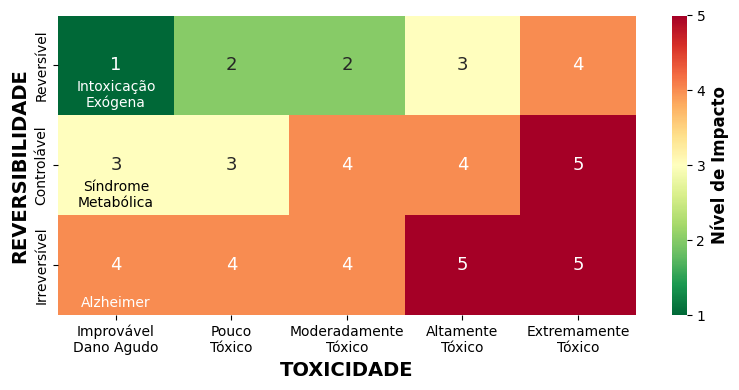

In [0]:
# Dados da matriz
matriz = {
    'Reversibilidade': ['Reversível', 'Controlável', 'Irreversível'],
    'Improvável\nDano Agudo': [1, 3, 4],
    'Pouco\nTóxico': [2, 3, 4],
    'Moderadamente\nTóxico': [2, 4, 4],
    'Altamente\nTóxico': [3, 4, 5],
    'Extremamente\nTóxico': [4, 5, 5]
}

df = pd.DataFrame(matriz).set_index('Reversibilidade')

plt.figure(figsize=(8, 4))
ax = sns.heatmap(df, annot=True, fmt='d', cmap='RdYlGn_r', cbar_kws={'label': 'Nível de Impacto'}, annot_kws={"fontsize":13})
plt.gca().collections[0].colorbar.set_label('Nível de Impacto', fontsize=12, fontweight='bold')
plt.xlabel('TOXICIDADE', fontsize=14, fontweight='bold')
plt.ylabel('REVERSIBILIDADE', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, ha='center')

# Mantém apenas números inteiros na barra de heatmap
colorbar = plt.gca().collections[0].colorbar
colorbar.set_ticks([1, 2, 3, 4, 5])
colorbar.set_ticklabels([1, 2, 3, 4, 5])

# Adiciona textos nos quadrantes solicitados
# Posições: (linha, coluna)
# Reversível & Improvável Dano Agudo: (0, 0)
ax.text(0 + 0.5, 0 + 0.95, "Intoxicação\nExógena", ha='center', va='bottom', fontsize=10, color='white')

# Controlável & Improvável Dano Agudo: (1, 0)
ax.text(0 + 0.5, 1 + 0.95, "Síndrome\nMetabólica", ha='center', va='bottom', fontsize=10, color='black')

# Irreversível & Improvável Dano Agudo: (2, 0)
ax.text(0 + 0.5, 2 + 0.95, "Alzheimer", ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('matriz_impacto.png', dpi=300)
plt.show()

#### **NÍVEL DE RISCO AMBIENTAL**

Nível de Risco Ambiental (R): é a multiplicação do nível de exposição ao risco (E) pelo nível de impacto (I),  sendo uma adaptação simplificada da probabilidade da ocorrência de um evento pela magnitude das consequencias de Sanchéz, (2013) e da probabilidade de ocorrência e seu efeito em potencial do PMBOK (PMI, 2017).

![image_1790167776814.png](./image_1790167776814.png "image_1790167776814.png")

em que I é o nível de impacto e E é o nível de exposição.

**Classificação do Nível de Risco** (Premissas):
- 0-4,9: Muito Baixo 
- 5 - 9,9: Baixo 
- 10 - 14,9: Moderado 
- 15 - 19,9: Alto 
- 20 - 25: Crítico



##### **NÍVEL DE EXPOSIÇÃO**

Nível de exposição ao risco (E): é estimado de forma simplificada para medir a possibilidade de ocorrência do risco.

**Referência**

A Hybrid Modeling Approach for Estimating the Exposure to Organophosphate Pesticide Drift in Sangamon County, Illinois (Afandi et al., 2024):
- Até 400 metros tem-se a maior concentração de produto da deriva
- Até 2000 metros há a redução até não haver mais concentração de produto da deriva

**--Premissas**
- O nível de exposição ao risco será estimado exclusivamente com base na distância da área de plantio até a área de risco de contaminação, sendo utilizado como proxy da exposição na ausência de dados detalhados sobre vias de transporte dos agrotóxicos (como direção de ventos, topografia e permeabilidade do solo);
- Assume-se, considerando a literatura sobre deriva aérea (Contiero et al., 2018), que quanto menor a distância, maior a concentração e a chance de contato com o produto da deriva, e vice-versa

**Classificação do Probabilidade de exposição** (Premissas):
- 1 Muito Baixo (acima de 2000m) 
- 2 Baixo (entre 1200m e 2000m) 
- 3 Moderado (entre 400m e 1200m)
- 4 Alto (entre 200m e 400m)
- 5 Crítico (até 200m) 



In [0]:
# Definição dos níveis de impacto e exposição
niveis = [1, 2, 3, 4, 5]

# Criação da matriz de produtos (R = I × E)
R = np.outer(niveis, niveis)  # linhas = Impacto, colunas = Exposição

# DataFrame para visualização com colunas invertidas
df = pd.DataFrame(R, 
                  index=[i for i in niveis],
                  columns=[i for i in niveis])

display(df)

1,2,3,4,5
1,2,3,4,5
2,4,6,8,10
3,6,9,12,15
4,8,12,16,20
5,10,15,20,25


##### **MATRIZ EXPOSIÇÃO E IMPACTO**

Matriz criada a partir multiplicação do nível de impacto do risco pelo nível de exposição, para determinar o nível de do risco, sendo uma representação adapatada da matriz de probabilidade e impacto do PMBOK (PMI, 2017).

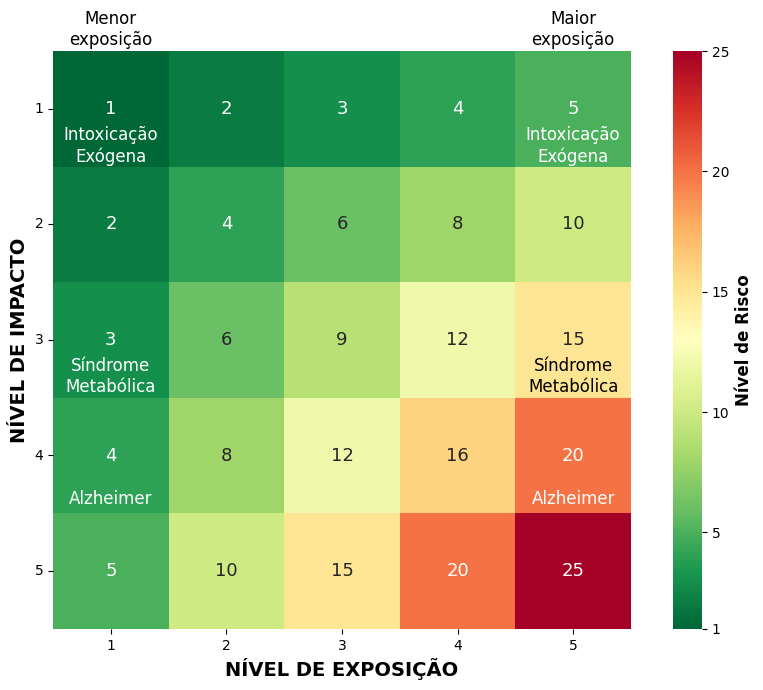

In [0]:
# Definição das classes do risco
def classificar_risco(valor):
    if valor < 5:
        return 'Muito Baixo'
    elif valor < 10:
        return 'Baixo'
    elif valor < 15:
        return 'Moderado'
    elif valor < 20:
        return 'Alto'
    else:
        return 'Crítico'

# Aplicar classificação a cada célula
classificacao = np.vectorize(classificar_risco)(R)

# Criar anotações apenas com o valor
annotations = np.empty(R.shape, dtype=object)
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        annotations[i, j] = f"{R[i, j]}"

# Plot do heatmap com números nos quadrantes
plt.figure(figsize=(9, 7))
ax = sns.heatmap(df, fmt='', cmap='RdYlGn_r', 
                 annot=annotations,  # insere números nos quadrantes
                 annot_kws={"fontsize":13},  # aumenta fonte dos quadrantes
                 cbar_kws={'label': 'Nível de Risco', 'ticks': [1, 5, 10, 15, 20, 25]},
                 square=True, linewidths=0, linecolor='gray')

plt.xlabel('NÍVEL DE EXPOSIÇÃO', fontsize=14, fontweight='bold')
plt.ylabel('NÍVEL DE IMPACTO', fontsize=14, fontweight='bold')
plt.yticks(rotation=360)  # rotaciona os números da legenda do eixo vertical

# Aumenta o tamanho e coloca em negrito a legenda do colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('Nível de Risco', fontsize=12, fontweight='bold')

# Adiciona nomenclaturas nos quadrantes solicitados
# Impacto = linhas, Exposição = colunas
# Impacto 1, Exposição 5: Intoxicação Exógena
ax.text(4 + 0.5, 0 + 0.65, "Intoxicação\nExógena", ha='center', va='top', fontsize=12, fontweight='normal', color='white')

# Impacto 3, Exposição 5: Síndrome Metabólica
ax.text(4 + 0.5, 2 + 0.65, "Síndrome\nMetabólica", ha='center', va='top', fontsize=12, fontweight='normal', color='black')

# Impacto 4, Exposição 5: Alzheimer
ax.text(4 + 0.5, 3 + 0.8, "Alzheimer", ha='center', va='top', fontsize=12, fontweight='normal', color='white')

# Adiciona nomenclaturas para Exposição igual a 1 (coluna 0)
# Impacto 1, Exposição 1: Intoxicação Exógena
ax.text(0 + 0.5, 0 + 0.65, "Intoxicação\nExógena", ha='center', va='top', fontsize=12, fontweight='normal', color='white')

# Impacto 3, Exposição 1: Síndrome Metabólica
ax.text(0 + 0.5, 2 + 0.65, "Síndrome\nMetabólica", ha='center', va='top', fontsize=12, fontweight='normal', color='white')

# Impacto 4, Exposição 1: Alzheimer
ax.text(0 + 0.5, 3 + 0.8, "Alzheimer", ha='center', va='top', fontsize=12, fontweight='normal', color='white')

# Adiciona textos "menos exposta" e "mais exposta"
ax.text(0 + 0.5, 0 - 0.02, "Menor\nexposição", ha='center', va='bottom', fontsize=12, color='black')
ax.text(4 + 0.5, 0 - 0.02, "Maior\nexposição", ha='center', va='bottom', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('matriz_Risco_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

#### **PERCENTUAL DO RISCO**

Percentual do Risco (Pr): é a quantificação do risco a partir adaptação da sua probabilidade de ocorrência para um índice percentual normalizado, utilizando-se o nível de risco (R) como base para essa conversão, de modo que o percentual pudesse ser usado como ponderador do valor financeiro do  (V). Para o cálculo, utilizou-se a normalização máxima e mínima para ajustar os valores do risco para o intervalo de 0% a 100%, como mostra a fórmula:

![image_1790130020926.png](./image_1790130020926.png "image_1790130020926.png")                                                    

em que: R é o nível de risco; Rmin é o menor de nível de risco, igual a 1; Rmax é o maior de nível de risco, igual 25.

O percentual do risco foi obtido para as duas distâncias entre a área de plantio e a comunidade, caracterizando os seguintes cenários espaciais:
- Menor distância: maior proximidade e maior exposição;
- Maior distância: menor proximidade e menor exposição.


In [0]:
# ==========================================
# 1. ENTRADA DE DADOS
# ==========================================
# Valores dos resultados reais gerados na matriz determinística de pontuação, com escala de 1 a 5
impactos = {
    'Intoxicação Exógena': 1.0,     
    'Síndrome Metabólica': 3.0,     
    'Alzheimer': 4.0                
}

# Cenários de distância mapeados para o Nível de Exposição (E) correspondente
cenarios_distancia = {
    '87,7m (E: Critico)': {'distancia': 87.7, 'E': 5},
    '2255,56m (E: Muito Baixo)': {'distancia': 2255.56, 'E': 1}
}

# Limites operacionais de Risco (R = I * E)
# R_min = 1 * 1 = 1 | R_max = 5 * 5 = 25
R_min = 1.0
R_max = 25.0

# ==========================================
# 2. PROCESSAMENTO MATEMÁTICO DOS CENÁRIOS
# ==========================================
dados_calculados = []

for efeito, I in impactos.items():
    for label_cenario, info in cenarios_distancia.items():
        E = info['E']
        
        # Cálculo do Risco: R = I * E
        R = I * E
        
        # Cálculo da Percentual do Risco: Pr = ((R - Rmin) / (Rmax - Rmin)) * 100
        Pr = ((R - R_min) / (R_max - R_min)) * 100
        
        # Armazenando os resultados estruturados
        dados_calculados.append({
            'Efeito': efeito,
            'Cenário Espacial': label_cenario,
            'Impacto (I)': I,
            'Exposição (E)': E,
            'Risco (R)': R,
            'Percentual Risco (Pr %)': Pr
        })

# Convertendo para DataFrame para visualização
df_resultados = pd.DataFrame(dados_calculados)

print("=== RESULTADOS ===")
print(df_resultados.to_string(index=False))
print("\n" + "="*40 + "\n")


=== RESULTADOS ===
             Efeito          Cenário Espacial  Impacto (I)  Exposição (E)  Risco (R)  Percentual Risco (Pr %)
Intoxicação Exógena        87,7m (E: Critico)          1.0              5        5.0                16.666667
Intoxicação Exógena 2255,56m (E: Muito Baixo)          1.0              1        1.0                 0.000000
Síndrome Metabólica        87,7m (E: Critico)          3.0              5       15.0                58.333333
Síndrome Metabólica 2255,56m (E: Muito Baixo)          3.0              1        3.0                 8.333333
          Alzheimer        87,7m (E: Critico)          4.0              5       20.0                79.166667
          Alzheimer 2255,56m (E: Muito Baixo)          4.0              1        4.0                12.500000




#### **PERCENTUAL DO RISCO RESIDUAL**

Percentual do Risco Residual (Pre): é a representação, em um índice percentual, do risco residual gerado após a implementação das ação de mitigação. É determinado pelo produto do percentual de risco (Pr) pela fração do coeficiente de eficácia (1 - e), que é o quanto a ação de controle reduz o risco.  O percentual de risco residual é uma adaptação do do conceito de risco residual (Vescio, 2022):

![image_1790171648514.png](./image_1790171648514.png "image_1790171648514.png")

Coeficiente de eficácia (e): é o coeficiente das ações de controle planejadas para a mitigação do risco, sendo o escore que mede o quão eficazes são as ações para a redução do risco. Ele foi estimado por meio da lógica "fuzzy", criando-se uma matriz que correlaciona as ações de mitigação propostas conforme detalhado abaixo.

**Ações de Mitigação do Risco**

O plano de mitigação simplificado foi criado para ilustrar as ações de mitigação do risco riscos à saúde provocados pela deriva aérea. Ele foi concebido como um processo de melhoria contínua baseado no ciclo PDCA (Planejar, Executar, Verificar e Agir) do PMBOK (PMI, 2021), considerando as seguintes etapas:
- Planejamento para previsão das condições meteorológicas (Planejar);
- Execução da tecnologia de aplicação de pulverização (Executar);
- Monitoramento por medição meteorológica (Verificar e Agir).

**Sistema de Inferência Fuzzy**

Tipo de modelo:
- Optou-se pelo modelo Mamdami por permitir a criação de regras linguísticas, sendo possível alinhar com as ações de mitigação do risco baseado no ciclo PDCA, e por fornecer saída gradual e contínua, adequada à natureza difusa da eficácia.

Variáveis linguísticas de entrada (ações de mitigação):
- Planejamento (meteorologia): Planejamento para previsão das condições meteorológicas;
- Tecnologia (pulverização): Execução da tecnologia de aplicação de pulverização;
- Monitoramento (meteorologia): Monitoramento por medição meteorológica.

    Possui três antecedentes, cada um com universo discreto [0, 10]

![image_1790176976310.png](./image_1790176976310.png "image_1790176976310.png")

Variáveis linguísticas de saída (coeficiente de eficácia):

Coeficiente de eficácia (e) com cinco termos linguísticos, universo contínuo [0, 1] e passo 0,01

![image_1790177283422.png](./image_1790177283422.png "image_1790177283422.png")

Base de Regras Fuzzy:
- Bloco 1 - Tecnologia de Aplicação Baixa (Regras C1–C9): sem a tecnologia adequada, as ações climáticas não conseguem conter a deriva, ainda que haja planejamento e monitoramento altos.
- Bloco 2 - Tecnologia de Aplicação Média (Regras C10–C18): a eficácia depende moderadamente do clima, apenas com planejamento e monitoramento alto se consegue alta eficácia, refletindo que a tecnologia média precisa de gestão robusta.
- Bloco 3 - Tecnologia de Aplicação Média (Regras C19–C27): garante-se alta eficácia se houver gestão do planejamento e monitoramento das ações climáticas.

    Princípio básico das regras: a tecnologia define o teto de eficácia, e o planejamento e monitoramento determinam quão próximo do teto o sistema opera.

Métodos de inferência e defuzzificação:
- Operador de implicação: mínimo;
- Agregação: máximo;
- Defuzzificação: centroide (centro de gravidade), padrão do scikit-fuzzy.
- Valor Crisp Representativo: Cada variável linguística de entrada é convertida para um valor crisp representativo, que são as aproximações arredondadas dos centroides das funções de pertinência de cada termo.

![image_1790180003707.png](./image_1790180003707.png "image_1790180003707.png")




In [0]:
# =============================================
# 0. BUSCAR VALORES DO DATAFRAME DA CÉLULA 13
# =============================================
# Salvar os riscos iniciais antes de df_resultados ser sobrescrito
df_riscos_celula13 = df_resultados.copy()
df_cenario_perto = df_riscos_celula13[df_riscos_celula13['Cenário Espacial'] == '87,7m (E: Critico)']
riscos_iniciais = {
    row['Efeito']: row['Percentual Risco (Pr %)']
    for _, row in df_cenario_perto.iterrows()
}

print("Riscos iniciais (Pr %) para o cenário 87,7m:")
for efeito, valor in riscos_iniciais.items():
    print(f"  {efeito}: {valor}")
print()

# ==========================================
# 1. DEFINIÇÃO DO UNIVERSO E VARIÁVEIS
# ==========================================
# Variáveis de Entrada (0 a 10)
pm = ctrl.Antecedent(np.arange(0, 11, 1), 'planejamento')
ta = ctrl.Antecedent(np.arange(0, 11, 1), 'tecnologia')
mm = ctrl.Antecedent(np.arange(0, 11, 1), 'monitoramento')

# Variável de Saída: Coeficiente de Eficácia e (0 a 1)
eficacia = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'eficacia')

# ==============================================
# 2. FUNÇÕES DE PERTINÊNCIA DE ENTRADA (0 A 10)
# ==============================================
for var in [pm, ta, mm]:
    var['baixa'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['media'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['alta'] = fuzz.trimf(var.universe, [5, 10, 10])

# ================================================
# 2. FUNÇÕES DE PERTINÊNCIA DA SAÍDA E (0 a 1)
# ================================================
# Ampliando de 3 para 5 níveis para maior sensibilidade
eficacia['muito_baixa'] = fuzz.trimf(eficacia.universe, [0, 0, 0.25])
eficacia['baixa']       = fuzz.trimf(eficacia.universe, [0.15, 0.3, 0.45])
eficacia['media']       = fuzz.trimf(eficacia.universe, [0.35, 0.5, 0.65])
eficacia['alta']        = fuzz.trimf(eficacia.universe, [0.55, 0.7, 0.85])
eficacia['muito_alta']  = fuzz.trimf(eficacia.universe, [0.75, 1.0, 1.0])

# ===========================================================
# 3. BASE DE REGRAS FUZZY (Cobrança do espaço de cenários)
# ===========================================================
regras = [
    # BLOCO 1: TECNOLOGIA BAIXA (Ações Climáticas não conseguem conter a deriva)
    ctrl.Rule(ta['baixa'] & pm['baixa'] & mm['baixa'], eficacia['muito_baixa']), # C1
    ctrl.Rule(ta['baixa'] & pm['baixa'] & mm['media'], eficacia['muito_baixa']), # C2
    ctrl.Rule(ta['baixa'] & pm['baixa'] & mm['alta'],  eficacia['muito_baixa']), # C3
    ctrl.Rule(ta['baixa'] & pm['media'] & mm['baixa'], eficacia['muito_baixa']), # C4
    ctrl.Rule(ta['baixa'] & pm['media'] & mm['media'], eficacia['baixa']), # C5
    ctrl.Rule(ta['baixa'] & pm['media'] & mm['alta'],  eficacia['baixa']), # C6
    ctrl.Rule(ta['baixa'] & pm['alta']  & mm['baixa'], eficacia['baixa']), # C7
    ctrl.Rule(ta['baixa'] & pm['alta']  & mm['media'], eficacia['media']), # C8
    ctrl.Rule(ta['baixa'] & pm['alta']  & mm['alta'],  eficacia['media']), # C9

    # BLOCO 2: TECNOLOGIA MÉDIA (Eficácia depende moderadamente do clima)
    ctrl.Rule(ta['media'] & pm['baixa'] & mm['baixa'], eficacia['muito_baixa']), # C10
    ctrl.Rule(ta['media'] & pm['baixa'] & mm['media'], eficacia['baixa']), # C11
    ctrl.Rule(ta['media'] & pm['baixa'] & mm['alta'],  eficacia['media']), # C12
    ctrl.Rule(ta['media'] & pm['media'] & mm['baixa'], eficacia['media']), # C13
    ctrl.Rule(ta['media'] & pm['media'] & mm['media'], eficacia['media']), # C14
    ctrl.Rule(ta['media'] & pm['media'] & mm['alta'],  eficacia['media']), # C15
    ctrl.Rule(ta['media'] & pm['alta']  & mm['baixa'], eficacia['media']), # C16
    ctrl.Rule(ta['media'] & pm['alta']  & mm['media'], eficacia['media']), # C17
    ctrl.Rule(ta['media'] & pm['alta']  & mm['alta'],  eficacia['alta']), # C18

    # BLOCO 3: TECNOLOGIA ALTA (Garante alta eficácia se houver gestão)
    ctrl.Rule(ta['alta'] & pm['baixa'] & mm['baixa'], eficacia['media']), # C19
    ctrl.Rule(ta['alta'] & pm['baixa'] & mm['media'], eficacia['media']), # C20
    ctrl.Rule(ta['alta'] & pm['baixa'] & mm['alta'],  eficacia['alta']), # C21
    ctrl.Rule(ta['alta'] & pm['media'] & mm['baixa'], eficacia['media']), # C22
    ctrl.Rule(ta['alta'] & pm['media'] & mm['media'], eficacia['alta']),  # C23
    ctrl.Rule(ta['alta'] & pm['media'] & mm['alta'],  eficacia['muito_alta']),  # C24
    ctrl.Rule(ta['alta'] & pm['alta']  & mm['baixa'], eficacia['alta']),  # C25
    ctrl.Rule(ta['alta'] & pm['alta']  & mm['media'], eficacia['muito_alta']),  # C26
    ctrl.Rule(ta['alta'] & pm['alta']  & mm['alta'],  eficacia['muito_alta'])   # C27
]

sistema_controle = ctrl.ControlSystem(regras)
simulacao = ctrl.ControlSystemSimulation(sistema_controle)

# ==========================================================================
# 4. GERAÇÃO DOS 27 CENÁRIOS
# ==========================================================================
# Nota: riscos_iniciais já foi definido no início da célula
# Valores representativos (crisp) para cada termo linguístico
niveis = {'Baixa': 1.0, 'Média': 5.0, 'Alta': 9.0}

resultados = []
cenario_id = 1

# Loop iterando pelas 3 ações e seus 3 níveis (3x3x3 = 27 cenários)
for nome_ta, val_ta in niveis.items():
    for nome_pm, val_pm in niveis.items():
        for nome_mm, val_mm in niveis.items():
            
            # Inserindo dados na simulação
            simulacao.input['tecnologia'] = val_ta
            simulacao.input['planejamento'] = val_pm
            simulacao.input['monitoramento'] = val_mm
            
            # Computando o resultado
            try:
                simulacao.compute()
                e = simulacao.output['eficacia']
            except:
                e = 0.0 # Fallback caso alguma regra não cubra uma transição extrema
            
            # Cálculo do Risco Residual (Pre = Pr * (1 - e))
            pre_alzheimer = riscos_iniciais['Alzheimer'] * (1 - e)
            pre_sindrome = riscos_iniciais['Síndrome Metabólica'] * (1 - e)
            pre_intox = riscos_iniciais['Intoxicação Exógena'] * (1 - e)
            
            # Salvando os dados
            resultados.append({
                'Cenário': f"C{cenario_id}",
                'Tecnologia (Do)': nome_ta,
                'Planejamento (Plan)': nome_pm,
                'Monitoramento (Check)': nome_mm,
                'Plan_Check': f"{nome_pm} / {nome_mm}", # Eixo Y do Heatmap
                'Eficácia (e)': e,
                'Pre_Alzheimer (%)': pre_alzheimer,
                'Pre_Sindrome (%)': pre_sindrome,
                'Pre_Intox (%)': pre_intox
            })
            cenario_id += 1

# Criando DataFrame para análise e exportação
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))



Riscos iniciais (Pr %) para o cenário 87,7m:
  Intoxicação Exógena: 16.666666666666664
  Síndrome Metabólica: 58.333333333333336
  Alzheimer: 79.16666666666666

Cenário Tecnologia (Do) Planejamento (Plan) Monitoramento (Check)    Plan_Check  Eficácia (e)  Pre_Alzheimer (%)  Pre_Sindrome (%)  Pre_Intox (%)
     C1           Baixa               Baixa                 Baixa Baixa / Baixa      0.086111          72.349537         53.310185      15.231481
     C2           Baixa               Baixa                 Média Baixa / Média      0.086111          72.349537         53.310185      15.231481
     C3           Baixa               Baixa                  Alta  Baixa / Alta      0.086111          72.349537         53.310185      15.231481
     C4           Baixa               Média                 Baixa Média / Baixa      0.086111          72.349537         53.310185      15.231481
     C5           Baixa               Média                 Média Média / Média      0.300000          55.416

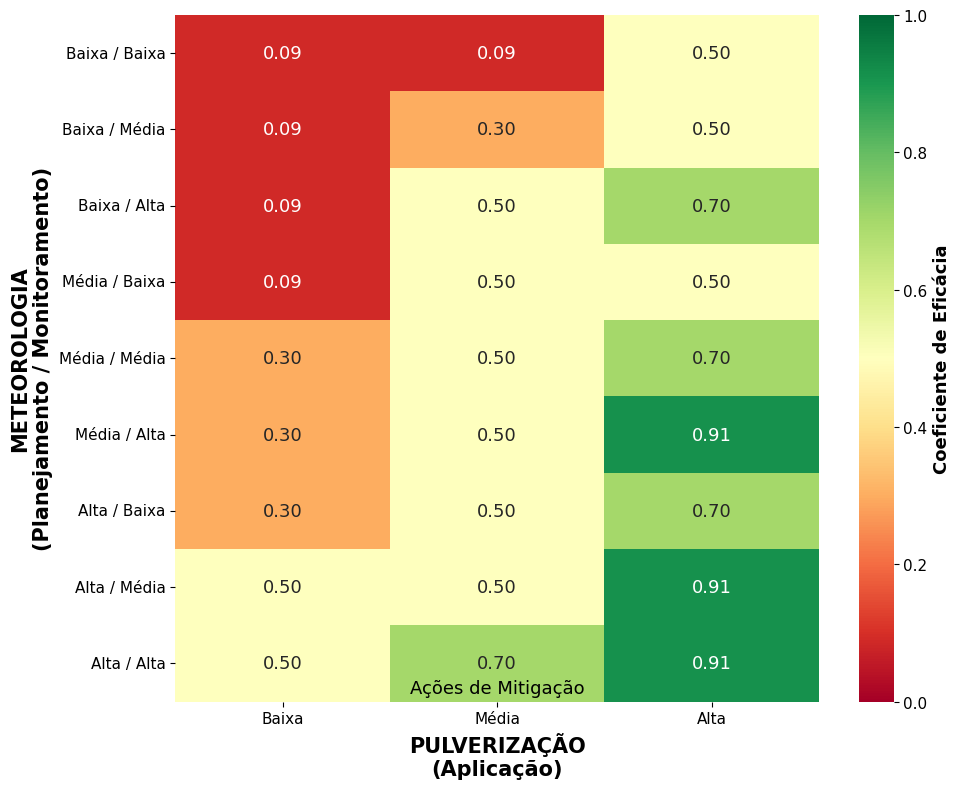

In [0]:
# ==========================================
# 5. PLOTAGEM DO MAPA DE CALOR
# ==========================================
# Pivotando a tabela para o formato de matriz (9 linhas x 3 colunas)
heatmap_data = df_resultados.pivot(index='Plan_Check', columns='Tecnologia (Do)', values='Eficácia (e)')

# Reordenando as linhas e colunas para fazer sentido lógico (Baixo -> Alto)
ordem_linhas = ['Baixa / Baixa', 'Baixa / Média', 'Baixa / Alta', 
                'Média / Baixa', 'Média / Média', 'Média / Alta', 
                'Alta / Baixa', 'Alta / Média', 'Alta / Alta']
ordem_colunas = ['Baixa', 'Média', 'Alta']

heatmap_data = heatmap_data.reindex(index=ordem_linhas, columns=ordem_colunas)

# Configurando o gráfico
plt.figure(figsize=(10, 8))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", 
                 linewidths=0, cbar_kws={'label': 'Coeficiente de Eficácia'},
                 vmin=0, vmax=1, annot_kws={"fontsize":13})

# Ajusta fonte e negrito da label do colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('Coeficiente de Eficácia', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)  # Aumenta tamanho dos números do eixo do coeficiente de eficácia

# Inserir a palavra "Ações" abaixo do número do quadrante alto / alto x médio
# Linha: 'Alto / Alto' (índice 8), Coluna: 'Médio' (índice 1)
ax.text(1 + 0.5, 8 + 0.70, "Ações de Mitigação", ha='center', va='top', fontsize=13, fontweight='normal', color='black')

#plt.title('Mapa de Calor dos 27 Cenários: Coeficiente de Eficácia (E)', fontsize=14, pad=15)
plt.ylabel('METEOROLOGIA\n(Planejamento / Monitoramento)', fontsize=15, fontweight='bold')
plt.xlabel('PULVERIZAÇÃO\n(Aplicação)', fontsize=15, fontweight='bold')

# Ajusta fonte dos textos dos eixos para 11
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

# Ajustando layout e salvando a imagem em alta resolução (Ideal para o TCC)
plt.tight_layout()
plt.savefig('matriz_eficacia.png', dpi=300)
plt.show()